In [21]:
#Generate hidden states for Qwen2-VL-7B-Instruct on COCO dataset


save_file_name = f"qwen2_image_concept_hidden_states_original_paper_validation"
data_dir =  "/mnt/abka03/xlvlm_data/coco_50_samples/val_all"

!export HF_HOME=/mnt/abka03/huggingface/hub


!cd ../ && python src/save_features.py \
    --model_name "Qwen/Qwen2-VL-7B-Instruct" \
    --dataset_name "image" \
    --dataset_size "500" \
    --data_dir $data_dir \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.norm" \
    --save_dir "/mnt/abka03/concept_extraction_result/CoX/coco/val" \
    --save_filename $save_file_name \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-05-14 23:40:39,042 - INFO - Loading model: Qwen/Qwen2-VL-7B-Instruct
2025-05-14 23:40:39,042 - INFO - Arguments:
2025-05-14 23:40:39,042 - INFO - seed: 0
2025-05-14 23:40:39,042 - INFO - model_name_or_path: Qwen/Qwen2-VL-7B-Instruct
2025-05-14 23:40:39,042 - INFO - processor_name: None
2025-05-14 23:40:39,042 - INFO - local_files_only: False
2025-05-14 23:40:39,042 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-05-14 23:40:39,043 - INFO - prompt_template: llava
2025-05-14 23:40:39,043 - INFO - prompt: Describe the image in detail.
2025-05-14 23:40:39,043 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_50_samples/val_all
2025-05-14 23:40:39,043 - INFO - annotation_file: annotations.json
2025-05-14 23:40:39,043 - INFO - questions_file: annotations.json
2025-05-14 23:40:39,043 - INFO - answer_type_to_answer: None
2025-05-14 23:40:39,043 - INFO - split: train
2025-0

In [17]:
# Geneate concept vectors for Qwen2-VL-7B-Instruct on COCO dataset

!export HF_HOME=/mnt/abka03/huggingface/hub


# Need to specify analysis type. This will decompose features, and extract both text, visual grounding
!analysis_name=decompose_activations_text_grounding_image_grounding

# Specify path where you have saved features on training data
saved_features_path=f"/mnt/abka03/concept_extraction_result/CoX/coco/train/features/save_hidden_states_noun_phrase_qwen2_image_concept_hidden_states_original_paper.pth"

# Where to store details about extracted concepts. Default directory is results/
results_filename=f"phrase_embeddings_concepts_combined" # Name of the file to save the results

# Specify the specific feature module you want to decompose

# LLaVA-v1.5
#feature_module=language_model.model.norm
#feature_module=language_model.model.layers.30

# Molmo-7B
#feature_module=model.transformer.blocks.27
#feature_module=model.transformer.ln_f
save_dir="/mnt/abka03/concept_extraction_result/CoX/coco/train/concept"
# Idefics2-8B
#feature_module=model.text_model.norm

# Qwen2-VL-7B
feature_module="model.norm"


decomposition="snmf" # Current options: snmf, kmeans, pca, simple
n_concepts=15# Size of dictionary learnt i.e. number of concepts

!cd ../ && python src/analyse_features.py \
--model_name  "Qwen/Qwen2-VL-7B-Instruct"  \
--analysis_name "decompose_activations_text_grounding_image_grounding" \
--features_path $saved_features_path \
--module_to_decompose $feature_module \
--num_concepts $n_concepts \
--decomposition_method $decomposition \
--save_filename $results_filename \
--save_dir $save_dir


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-05-14 23:33:49,311 - INFO - Arguments:
2025-05-14 23:33:49,311 - INFO - seed: 0
2025-05-14 23:33:49,311 - INFO - model_name_or_path: Qwen/Qwen2-VL-7B-Instruct
2025-05-14 23:33:49,311 - INFO - processor_name: None
2025-05-14 23:33:49,311 - INFO - local_files_only: False
2025-05-14 23:33:49,311 - INFO - cache_dir: None
2025-05-14 23:33:49,311 - INFO - prompt_template: llava
2025-05-14 23:33:49,311 - INFO - prompt: Describe the image in detail.
2025-05-14 23:33:49,311 - INFO - data_dir: data/
2025-05-14 23:33:49,311 - INFO - annotation_file: annotations.json
2025-05-14 23:33:49,311 - INFO - questions_file: annotations.json
2025-05-14 23:33:49,311 - INFO - answer_type_to_answer: None
2025-05-14 23:33:49,311 - INFO - split: train
2025-05-14 23:33:49,311 - INFO - dataset_size: -1
2025-05-14 23:33:49,311 - INFO - dataset_name: coco
2025-05-14 23:33:49,311 - INFO - batch_s

In [18]:
# Import libraries to visualize the results
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import matplotlib
import pydicom
from PIL import Image
import numpy as np
import os
import torch
print("Matplotlib version for info:", matplotlib.__version__)

Matplotlib version for info: 3.9.4


dict_keys(['concepts', 'activations', 'decomposition_method', 'text_grounding', 'image_grounding_paths', 'analysis_model'])


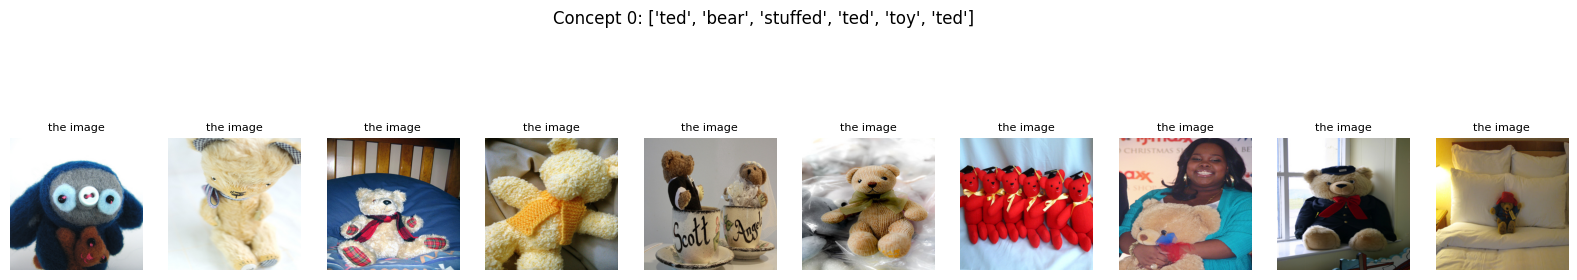

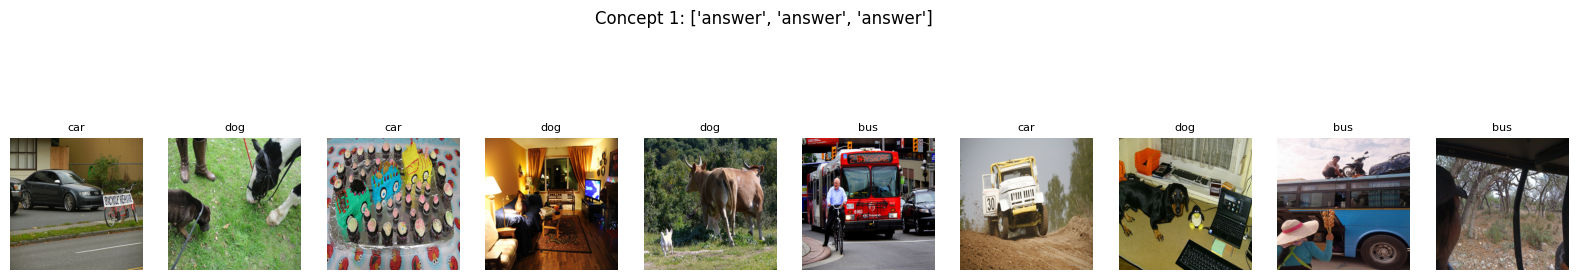

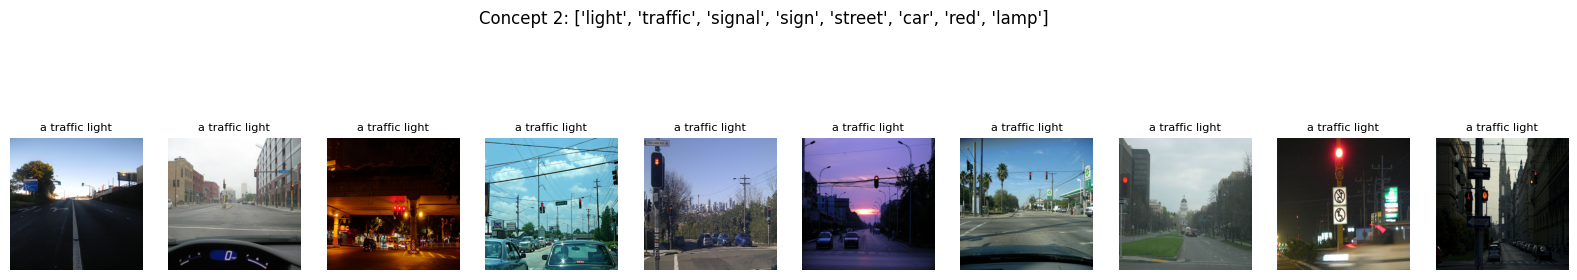

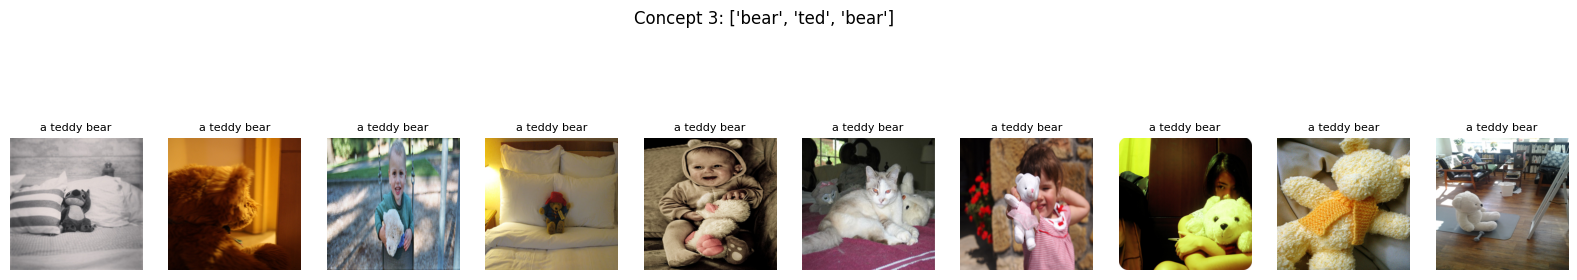

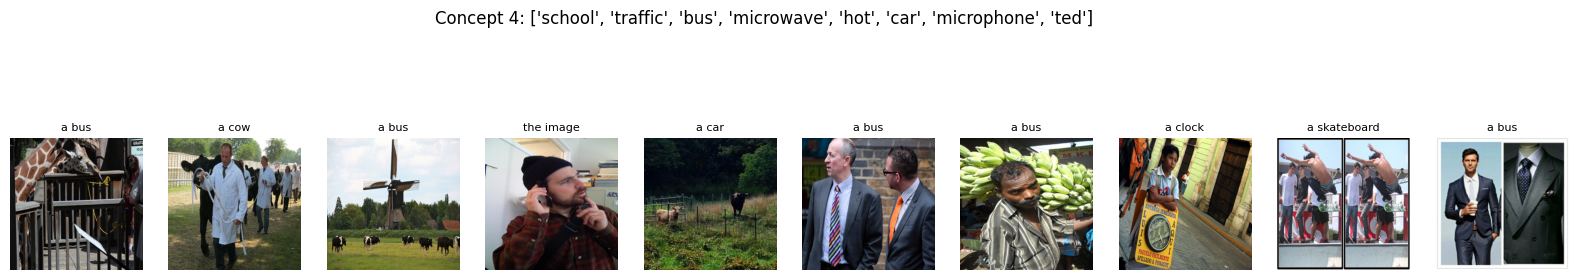

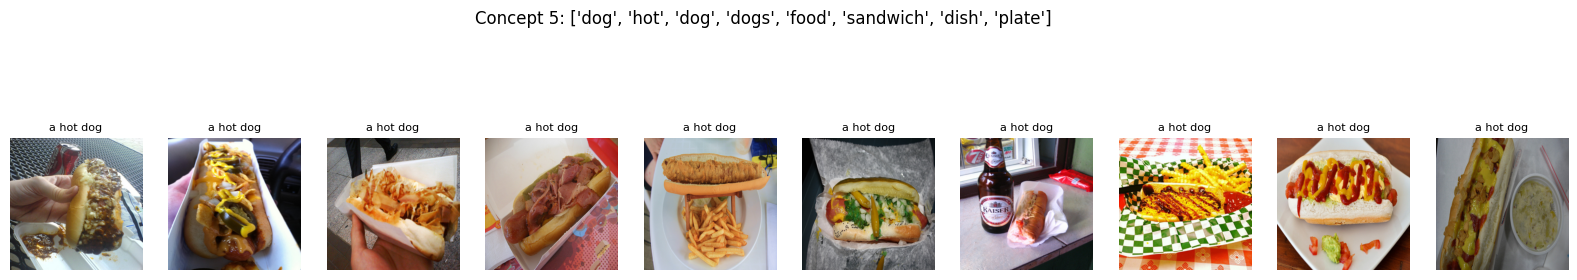

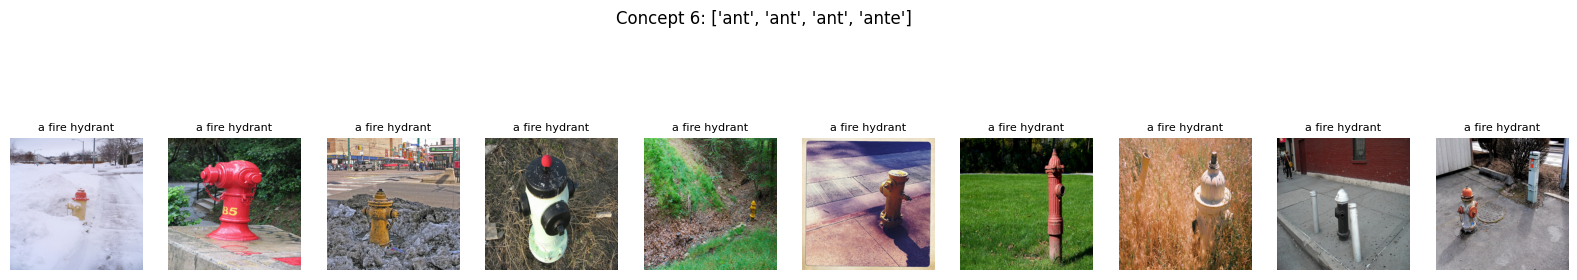

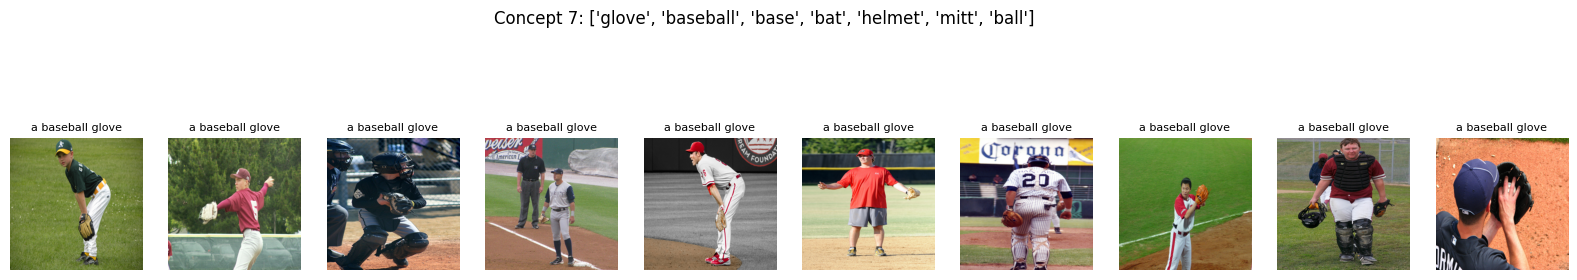

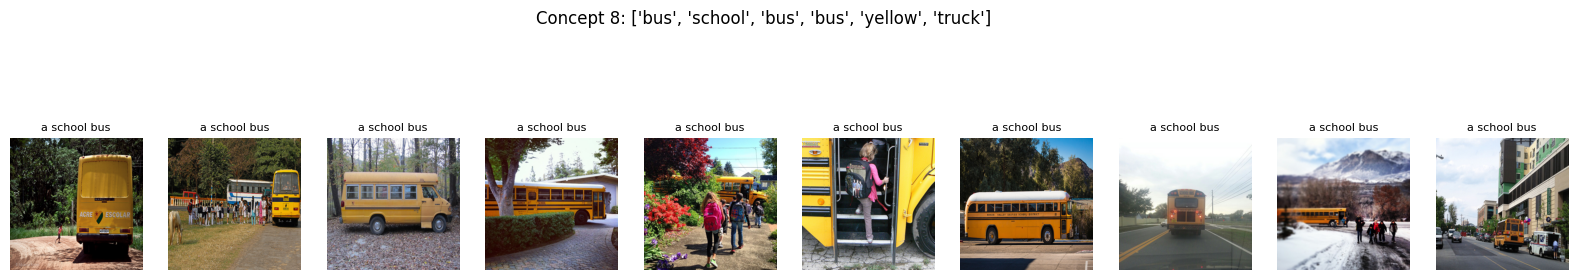

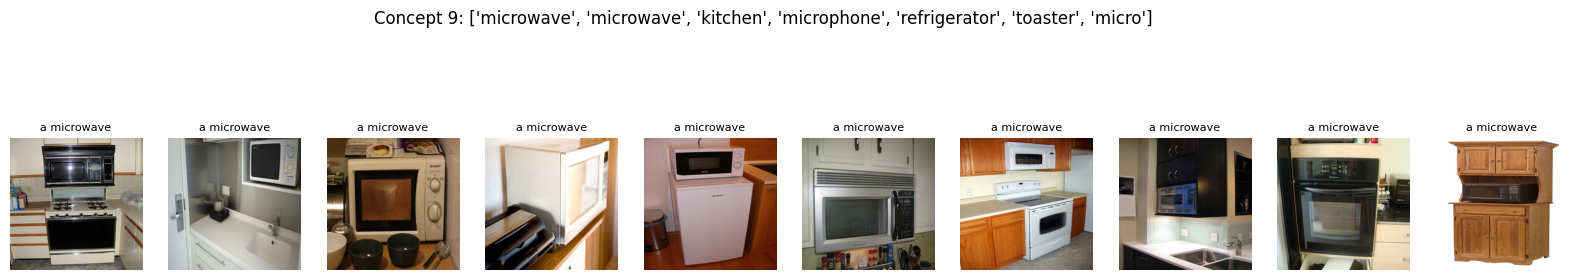

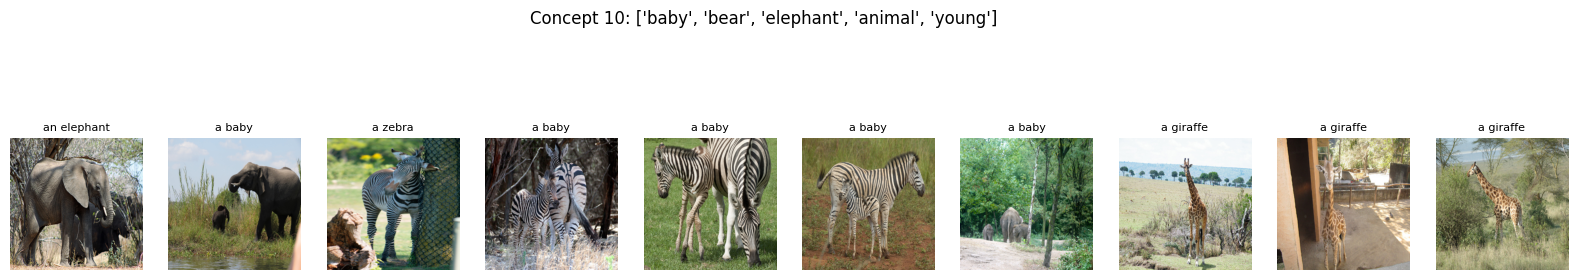

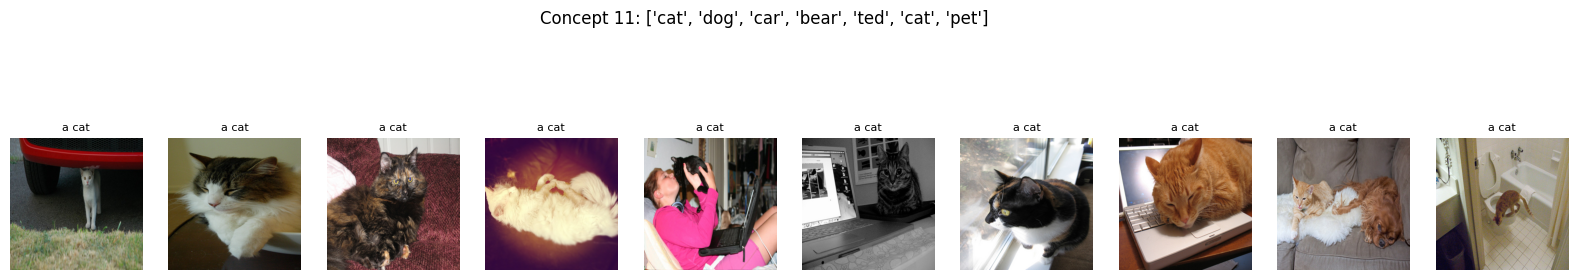

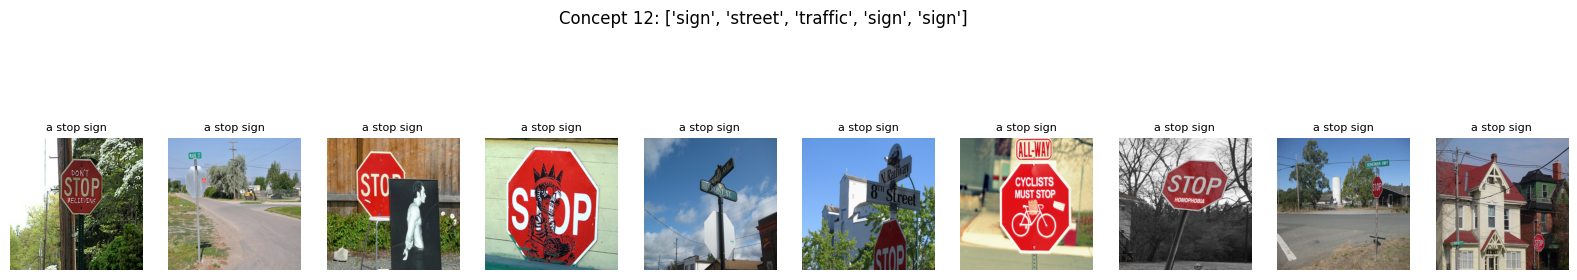

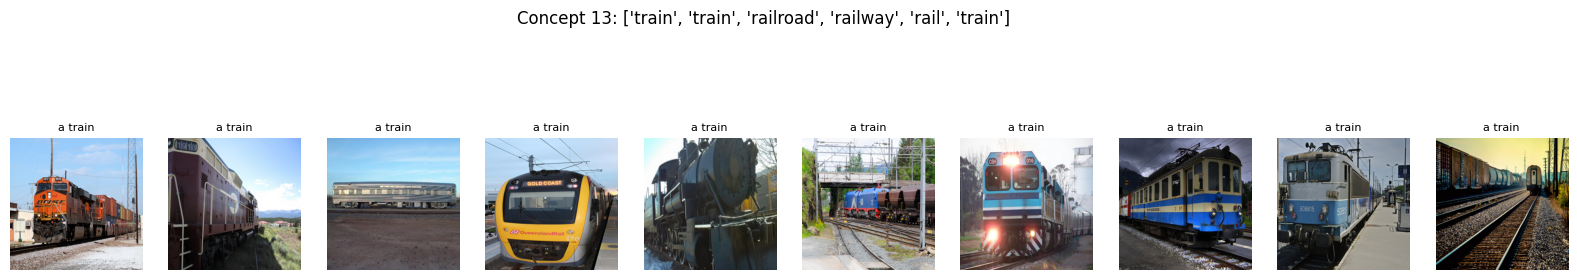

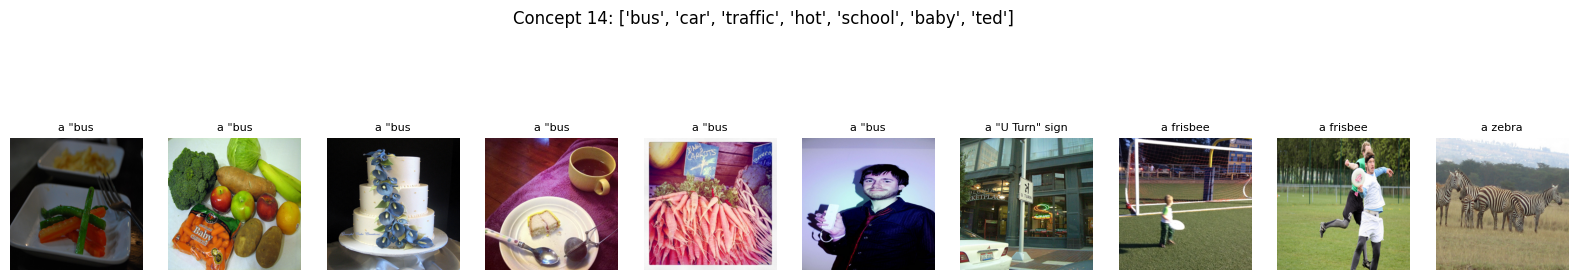

In [19]:

num_concepts = 15 # Number of concepts to visualize

results_filename = "/mnt/abka03/concept_extraction_result/CoX/coco/train/concept/decompose_activations_text_grounding_image_grounding_phrase_embeddings_concepts_combined.pth"
concept_data = torch.load(results_filename)
print(concept_data.keys())
concept_image = concept_data["image_grounding_paths"]
concept_text = concept_data['text_grounding']
def load_image(file_path):
    """
    Load an image file (.dcm, .jpeg, .png).

    Parameters:
        file_path (str): The path to the image file.

    Returns:
        numpy.ndarray: The loaded image as a NumPy array.
    """
    # Extract the file extension
    ext = os.path.splitext(file_path)[-1].lower()

    if ext == ".dcm":
        # Load DICOM file
        dicom_data = pydicom.dcmread(file_path)
        image = dicom_data.pixel_array
        return image

    elif ext in [".jpeg", ".jpg", ".png"]:
        # Load JPEG or PNG file
        image = Image.open(file_path)
        return np.array(image)

    else:
        raise ValueError(f"Unsupported file format: {ext}")


def visualize_grounding(concept_idx, concept_text, image_paths):
    concept_names = concept_text[concept_idx]
    paths = image_paths[concept_idx]
    num_imgs = len(paths)
    images = []
    for path in paths:
        concept,path = path.split("@")
    
        concept_names.append(concept)
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)
    width = num_imgs*2+0.1
    fig = plt.figure(figsize=(width, width/5))
    for i in range(num_imgs):
        fig.add_subplot(1, num_imgs, i+1)
        plt.imshow(images[i])
        plt.axis('off')
    fig.suptitle('Concept ' + str(concept_idx) + ': ' + str(concept_names)) 


def visualize_grounding(concept_idx, concept_text, image_paths):
    concept_names = concept_text[concept_idx]
    paths = image_paths[concept_idx]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept)
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    width = num_imgs * 2 + 0.1
    fig = plt.figure(figsize=(width, width / 5))

    for i in range(num_imgs):
        ax = fig.add_subplot(1, num_imgs, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        ax.set_title(concept_list[i], fontsize=8)  # Adding concept names below each image

    fig.suptitle('Concept ' + str(concept_idx) + ': ' + str( concept_names))
    plt.show()


for k in range(num_concepts):
    visualize_grounding(k, concept_text, concept_image)